# Base Unificada — Reconstrução por Retornos

Resolve a **descontinuidade na fronteira 2015/S2 → 2016/S1** entre as duas bases de preços.

## O problema

As duas bases usam `adj_close`, mas com **datas de normalização diferentes**:
- Base do professor: adj_close tal como baixado em ~dez/2015
- Extensão: adj_close tal como baixado em 2026

Um split ocorrido entre 2016 e 2025 (ex: split 4-for-1 da AAPL em ago/2020) faz o Yahoo retroativamente dividir todos os preços históricos por 4. Assim, o mesmo dia tem preços diferentes dependendo de *quando* o download foi feito. Ao concatenar as duas bases, surge um salto artificial na fronteira.

## A solução

Os **retornos diários** $r_t = P_t / P_{t-1} - 1$ são imunes a essa diferença de normalização, pois o fator de ajuste cancela. A ideia do professor é:

1. Manter os preços da base do professor intactos até 2015/S2
2. Para cada ticker na interseção, **escalar toda a série da extensão** de modo que seu primeiro valor coincida com o último preço da base do professor
3. Isso preserva todos os retornos diários intra-extensão e elimina o salto artificial

$$P_{\text{uni}}(t) = P_{\text{prof}}(t_{\text{fim}}) \cdot \frac{P_{\text{ext}}(t)}{P_{\text{ext}}(t_0)}$$

onde $t_{\text{fim}}$ é o último dia do professor e $t_0$ é o primeiro dia da extensão.

> **Esta base é independente de `base_completa.csv`** — não altera nenhum notebook existente.
> Para usá-la em `pairs_formation.ipynb`, basta trocar o arquivo de entrada.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

META_COLS = ['year', 'semester', 'period', 'day_in_semester', 'total_days_sem']

## 2. Carregando as bases

In [2]:
prof = pd.read_csv('../data_bases/professor_consolidado.csv', parse_dates=['date'])
ext  = pd.read_csv('../data_bases/extensao_2016_2025.csv',   parse_dates=['date'])

prof = prof.set_index('date')
ext  = ext.set_index('date')

prof_tickers = [c for c in prof.columns if c not in META_COLS]
ext_tickers  = [c for c in ext.columns  if c not in META_COLS]

tickers_ambas    = sorted(set(prof_tickers) & set(ext_tickers))
tickers_so_prof  = sorted(set(prof_tickers) - set(ext_tickers))
tickers_so_ext   = sorted(set(ext_tickers)  - set(prof_tickers))

print(f"Professor : {len(prof_tickers):4d} tickers | {prof.index[0].date()} → {prof.index[-1].date()}")
print(f"Extensão  : {len(ext_tickers):4d} tickers | {ext.index[0].date()} → {ext.index[-1].date()}")
print()
print(f"Interseção (âncora disponível) : {len(tickers_ambas):4d}")
print(f"Só no professor (sem extensão) : {len(tickers_so_prof):4d}")
print(f"Só na extensão  (sem âncora)   : {len(tickers_so_ext):4d}")

Professor : 1100 tickers | 1990-07-03 → 2015-12-30
Extensão  :  708 tickers | 2016-01-04 → 2025-12-31

Interseção (âncora disponível) :  465
Só no professor (sem extensão) :  635
Só na extensão  (sem âncora)   :  243


## 3. Diagnóstico: dimensão do problema

Para os tickers na interseção, calculamos o **fator de escala** entre o último preço do professor e o primeiro preço da extensão. Um fator ≠ 1 indica a descontinuidade que queremos corrigir.

=== Fator de escala  prof_last / ext_first ===
Mediana  : 1.2996
Média    : 1.9210
Min      : 0.0993  (DELL)
Max      : 54.1198  (CMG)

Tickers com fator > 1.5 (splits relevantes): 123
Tickers com fator < 0.7 (dividendos/reverse): 9
Tickers com fator ≈ 1.0 (±5%): 55


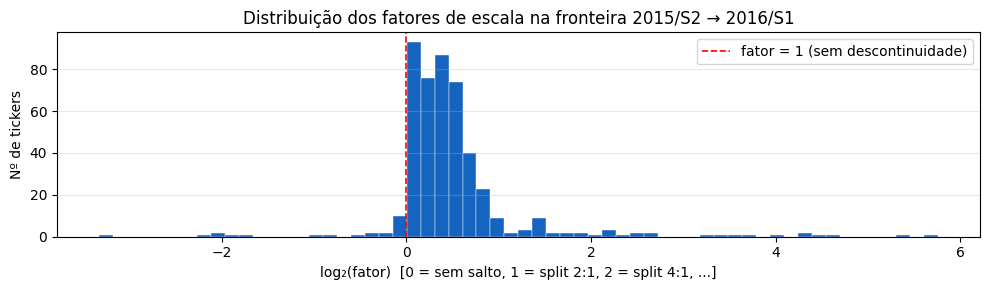

In [3]:
fatores = {}
for ticker in tickers_ambas:
    prof_valid = prof[ticker].dropna()
    ext_valid  = ext[ticker].dropna()
    if len(prof_valid) == 0 or len(ext_valid) == 0:
        continue
    fatores[ticker] = prof_valid.iloc[-1] / ext_valid.iloc[0]

fatores_s = pd.Series(fatores)

print("=== Fator de escala  prof_last / ext_first ===")
print(f"Mediana  : {fatores_s.median():.4f}")
print(f"Média    : {fatores_s.mean():.4f}")
print(f"Min      : {fatores_s.min():.4f}  ({fatores_s.idxmin()})")
print(f"Max      : {fatores_s.max():.4f}  ({fatores_s.idxmax()})")
print(f"\nTickers com fator > 1.5 (splits relevantes): {(fatores_s > 1.5).sum()}")
print(f"Tickers com fator < 0.7 (dividendos/reverse): {(fatores_s < 0.7).sum()}")
print(f"Tickers com fator ≈ 1.0 (±5%): {((fatores_s > 0.95) & (fatores_s < 1.05)).sum()}")

# Histograma dos fatores
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(np.log2(fatores_s), bins=60, color='#1565C0', edgecolor='white', lw=0.3)
ax.axvline(0, color='red', lw=1.2, ls='--', label='fator = 1 (sem descontinuidade)')
ax.set_xlabel('log₂(fator)  [0 = sem salto, 1 = split 2:1, 2 = split 4:1, ...]')
ax.set_ylabel('Nº de tickers')
ax.set_title('Distribuição dos fatores de escala na fronteira 2015/S2 → 2016/S1')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Exemplos do problema — salto visível na fronteira

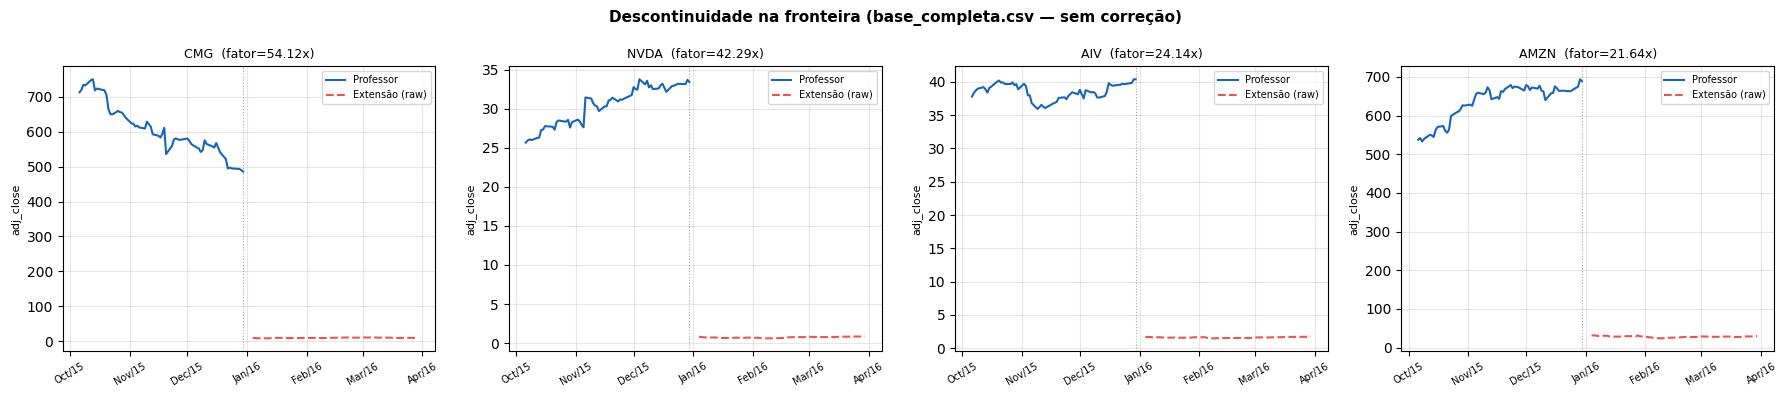

In [4]:
# Escolhe tickers com fatores bem afastados de 1 (mais visíveis)
tickers_exemplo = (
    fatores_s
    .reindex(tickers_ambas)
    .dropna()
    .pipe(lambda s: s[(s - 1).abs() > 0.3])  # fator pelo menos 30% diferente de 1
    .abs()
    .nlargest(4)
    .index.tolist()
)
if not tickers_exemplo:
    tickers_exemplo = ['AAPL', 'MSFT', 'AMZN', 'GOOGL']
    tickers_exemplo = [t for t in tickers_exemplo if t in tickers_ambas][:4]

fig, axes = plt.subplots(1, len(tickers_exemplo), figsize=(4.5 * len(tickers_exemplo), 4))
if len(tickers_exemplo) == 1:
    axes = [axes]
fig.suptitle('Descontinuidade na fronteira (base_completa.csv — sem correção)', fontsize=11, fontweight='bold')

JANELA = 60  # dias para mostrar antes e depois da fronteira

for ax, ticker in zip(axes, tickers_exemplo):
    p_tail = prof[ticker].dropna().iloc[-JANELA:]
    e_head = ext[ticker].dropna().iloc[:JANELA]

    ax.plot(p_tail.index, p_tail.values, color='#1565C0', lw=1.5, label='Professor')
    ax.plot(e_head.index, e_head.values, color='#ef5350', lw=1.5, ls='--', label='Extensão (raw)')
    ax.axvline(prof.index[-1], color='gray', lw=0.8, ls=':', alpha=0.7)
    ax.set_title(f'{ticker}  (fator={fatores_s[ticker]:.2f}x)', fontsize=9)
    ax.set_ylabel('adj_close', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Reconstrução

Para cada ticker na **interseção** professor ∩ extensão:

$$P_{\text{uni}}(t) = P_{\text{prof}}(t_{\text{fim}}) \cdot \frac{P_{\text{ext}}(t)}{P_{\text{ext}}(t_0)}$$

- $P_{\text{prof}}(t_{\text{fim}})$: último preço válido do professor (âncora de magnitude)
- $P_{\text{ext}}(t_0)$: primeiro preço válido da extensão
- Todos os retornos diários intra-extensão são **preservados exatamente**
- A série começa em $P_{\text{prof}}(t_{\text{fim}})$ no dia $t_0$ — sem salto

Para tickers **só na extensão** (243 tickers sem âncora): mantidos como estão.  
Para tickers **só no professor** (635 tickers delistados): mantidos como estão.

In [5]:
def reconstruir_extensao(prof_series, ext_series):
    """
    Escala ext_series de modo que seu primeiro valor válido coincida
    com o último valor válido de prof_series.
    Retorna a série reescalada (mesmos índices que ext_series).
    """
    prof_valid = prof_series.dropna()
    ext_valid  = ext_series.dropna()
    if len(prof_valid) == 0 or len(ext_valid) == 0:
        return ext_series  # sem âncora: devolve como está
    fator = prof_valid.iloc[-1] / ext_valid.iloc[0]
    return ext_series * fator


# Constrói a parte da extensão com preços reconstruídos
# Usa dict para evitar inserção coluna-a-coluna (PerformanceWarning)
cols_rec = {}
n_ancorados = 0
n_sem_ancora = 0

for ticker in ext_tickers:
    if ticker in tickers_ambas:
        cols_rec[ticker] = reconstruir_extensao(prof[ticker], ext[ticker])
        n_ancorados += 1
    else:
        cols_rec[ticker] = ext[ticker]  # só na extensão: sem alteração
        n_sem_ancora += 1

ext_rec = pd.concat([ext[META_COLS], pd.DataFrame(cols_rec)], axis=1)

print(f"Tickers reconstruídos com âncora  : {n_ancorados}")
print(f"Tickers mantidos sem alteração    : {n_sem_ancora} (só na extensão)")

Tickers reconstruídos com âncora  : 465
Tickers mantidos sem alteração    : 243 (só na extensão)


## 5. Concatenação em base_unificada.csv

Estrutura idêntica a `base_completa.csv` — pode ser usada diretamente em `pairs_formation.ipynb` e `pairs_trading.ipynb`.

In [6]:
base_uni = pd.concat([prof, ext_rec], axis=0).sort_index()

# Garante que não há datas duplicadas (professor termina em 2015-12-30, extensão começa em 2016-01-04)
n_dup = base_uni.index.duplicated().sum()
if n_dup > 0:
    print(f"AVISO: {n_dup} datas duplicadas — mantendo primeira ocorrência.")
    base_uni = base_uni[~base_uni.index.duplicated(keep='first')]

n_tickers_uni = len([c for c in base_uni.columns if c not in META_COLS])

print(f"base_unificada: {base_uni.shape[0]:,} dias × {n_tickers_uni} tickers")
print(f"Período       : {base_uni.index[0].date()} → {base_uni.index[-1].date()}")
print(f"Datas duplicadas: {n_dup}")

base_unificada: 8,939 dias × 1343 tickers
Período       : 1990-07-03 → 2025-12-31
Datas duplicadas: 0


## 6. Validação

Três verificações:
1. **Continuidade**: a série unificada não tem salto na fronteira
2. **Retornos preservados**: retornos diários na extensão são idênticos antes e depois da reconstrução
3. **Magnitude preservada**: a escala da base do professor é mantida

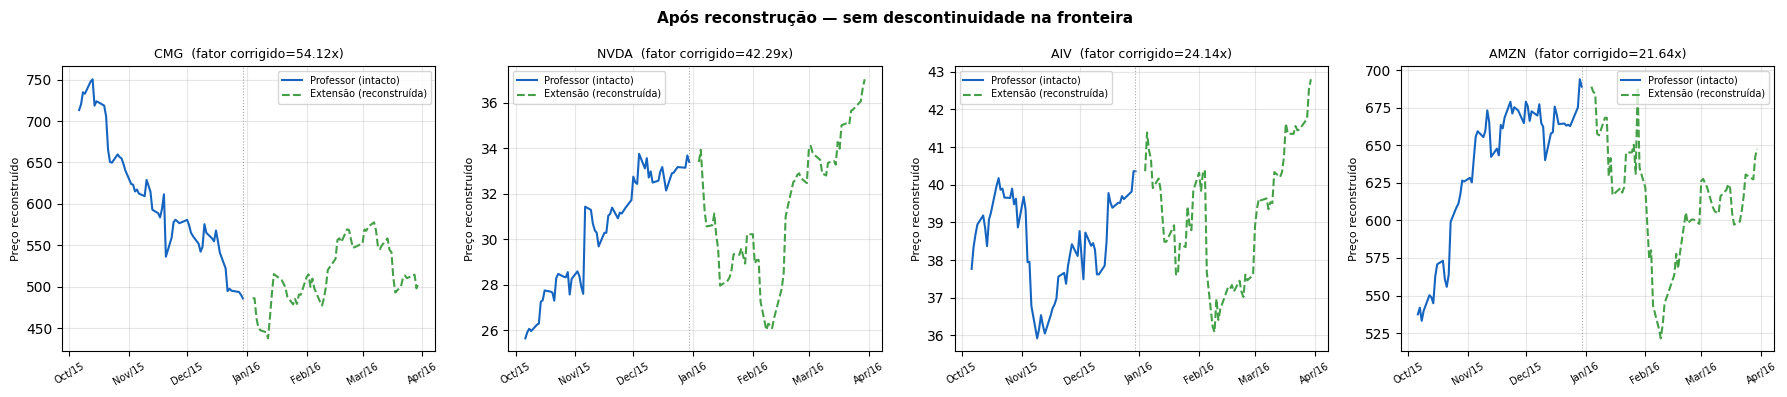

In [7]:
# --- 6.1 Continuidade visual ---
fig, axes = plt.subplots(1, len(tickers_exemplo), figsize=(4.5 * len(tickers_exemplo), 4))
if len(tickers_exemplo) == 1:
    axes = [axes]
fig.suptitle('Após reconstrução — sem descontinuidade na fronteira', fontsize=11, fontweight='bold')

for ax, ticker in zip(axes, tickers_exemplo):
    serie_uni = base_uni[ticker].dropna()
    p_tail    = serie_uni[serie_uni.index <= prof.index[-1]].iloc[-JANELA:]
    e_head    = serie_uni[serie_uni.index >= ext.index[0]].iloc[:JANELA]

    ax.plot(p_tail.index, p_tail.values, color='#1565C0', lw=1.5, label='Professor (intacto)')
    ax.plot(e_head.index, e_head.values, color='#43A047', lw=1.5, ls='--', label='Extensão (reconstruída)')
    ax.axvline(prof.index[-1], color='gray', lw=0.8, ls=':', alpha=0.7)
    ax.set_title(f'{ticker}  (fator corrigido={fatores_s[ticker]:.2f}x)', fontsize=9)
    ax.set_ylabel('Preço reconstruído', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# --- 6.2 Retornos diários: extensão raw vs extensão reconstruída ---
print("=== Verificação: retornos diários ext_raw vs ext_reconstruída ===")
print("(devem ser idênticos — escalar por uma constante não altera retornos)")
print()

for ticker in tickers_exemplo[:3]:
    r_raw  = ext[ticker].pct_change().dropna()
    r_rec  = ext_rec[ticker].pct_change().dropna()
    diff   = (r_raw - r_rec).abs().max()
    print(f"{ticker:12s}  max |r_raw - r_rec| = {diff:.2e}  {'✓ OK' if diff < 1e-10 else '✗ ERRO'}")

=== Verificação: retornos diários ext_raw vs ext_reconstruída ===
(devem ser idênticos — escalar por uma constante não altera retornos)

CMG           max |r_raw - r_rec| = 2.22e-16  ✓ OK
NVDA          max |r_raw - r_rec| = 2.22e-16  ✓ OK
AIV           max |r_raw - r_rec| = 2.22e-16  ✓ OK


C:\Users\jvlei\AppData\Local\Temp\ipykernel_6184\686769302.py:7: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  r_raw  = ext[ticker].pct_change().dropna()
C:\Users\jvlei\AppData\Local\Temp\ipykernel_6184\686769302.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  r_rec  = ext_rec[ticker].pct_change().dropna()


In [9]:
# --- 6.3 Magnitude: último preço do professor vs primeiro da extensão reconstruída ---
print("=== Verificação: continuidade de preço na fronteira ===")
print(f"{'Ticker':12s}  {'Prof last':>12s}  {'Ext rec first':>13s}  {'Ratio':>8s}")
print("-" * 55)

erros = []
for ticker in tickers_ambas:
    prof_last  = prof[ticker].dropna().iloc[-1] if len(prof[ticker].dropna()) > 0 else np.nan
    ext_first  = ext_rec[ticker].dropna().iloc[0] if len(ext_rec[ticker].dropna()) > 0 else np.nan
    if np.isnan(prof_last) or np.isnan(ext_first):
        continue
    ratio = ext_first / prof_last
    if abs(ratio - 1) > 0.01:   # tolerância 1%
        erros.append((ticker, prof_last, ext_first, ratio))

# Mostra primeiros 5 exemplos de tickers corretos
for ticker in tickers_exemplo[:5]:
    if ticker in tickers_ambas:
        prof_last = prof[ticker].dropna().iloc[-1]
        ext_first = ext_rec[ticker].dropna().iloc[0]
        print(f"{ticker:12s}  {prof_last:12.4f}  {ext_first:13.4f}  {ext_first/prof_last:8.6f}")

print()
if erros:
    print(f"AVISO: {len(erros)} tickers com ratio ≠ 1 após reconstrução:")
    for ticker, pl, ef, r in erros[:5]:
        print(f"  {ticker}: {pl:.4f} → {ef:.4f}  ratio={r:.4f}")
else:
    print(f"Todos os {len(tickers_ambas)} tickers com âncora: ratio ≈ 1.000000 ✓")

=== Verificação: continuidade de preço na fronteira ===
Ticker           Prof last  Ext rec first     Ratio
-------------------------------------------------------
CMG               485.7900       485.7900  1.000000
NVDA               33.3900        33.3900  1.000000
AIV                40.3600        40.3600  1.000000
AMZN              689.0700       689.0700  1.000000

Todos os 465 tickers com âncora: ratio ≈ 1.000000 ✓


### 6.4 Comparação visual — série completa professor + extensão

Compara `base_completa.csv` (concatenação direta, com salto) vs `base_unificada.csv` (reconstruída, sem salto) para alguns tickers representativos.

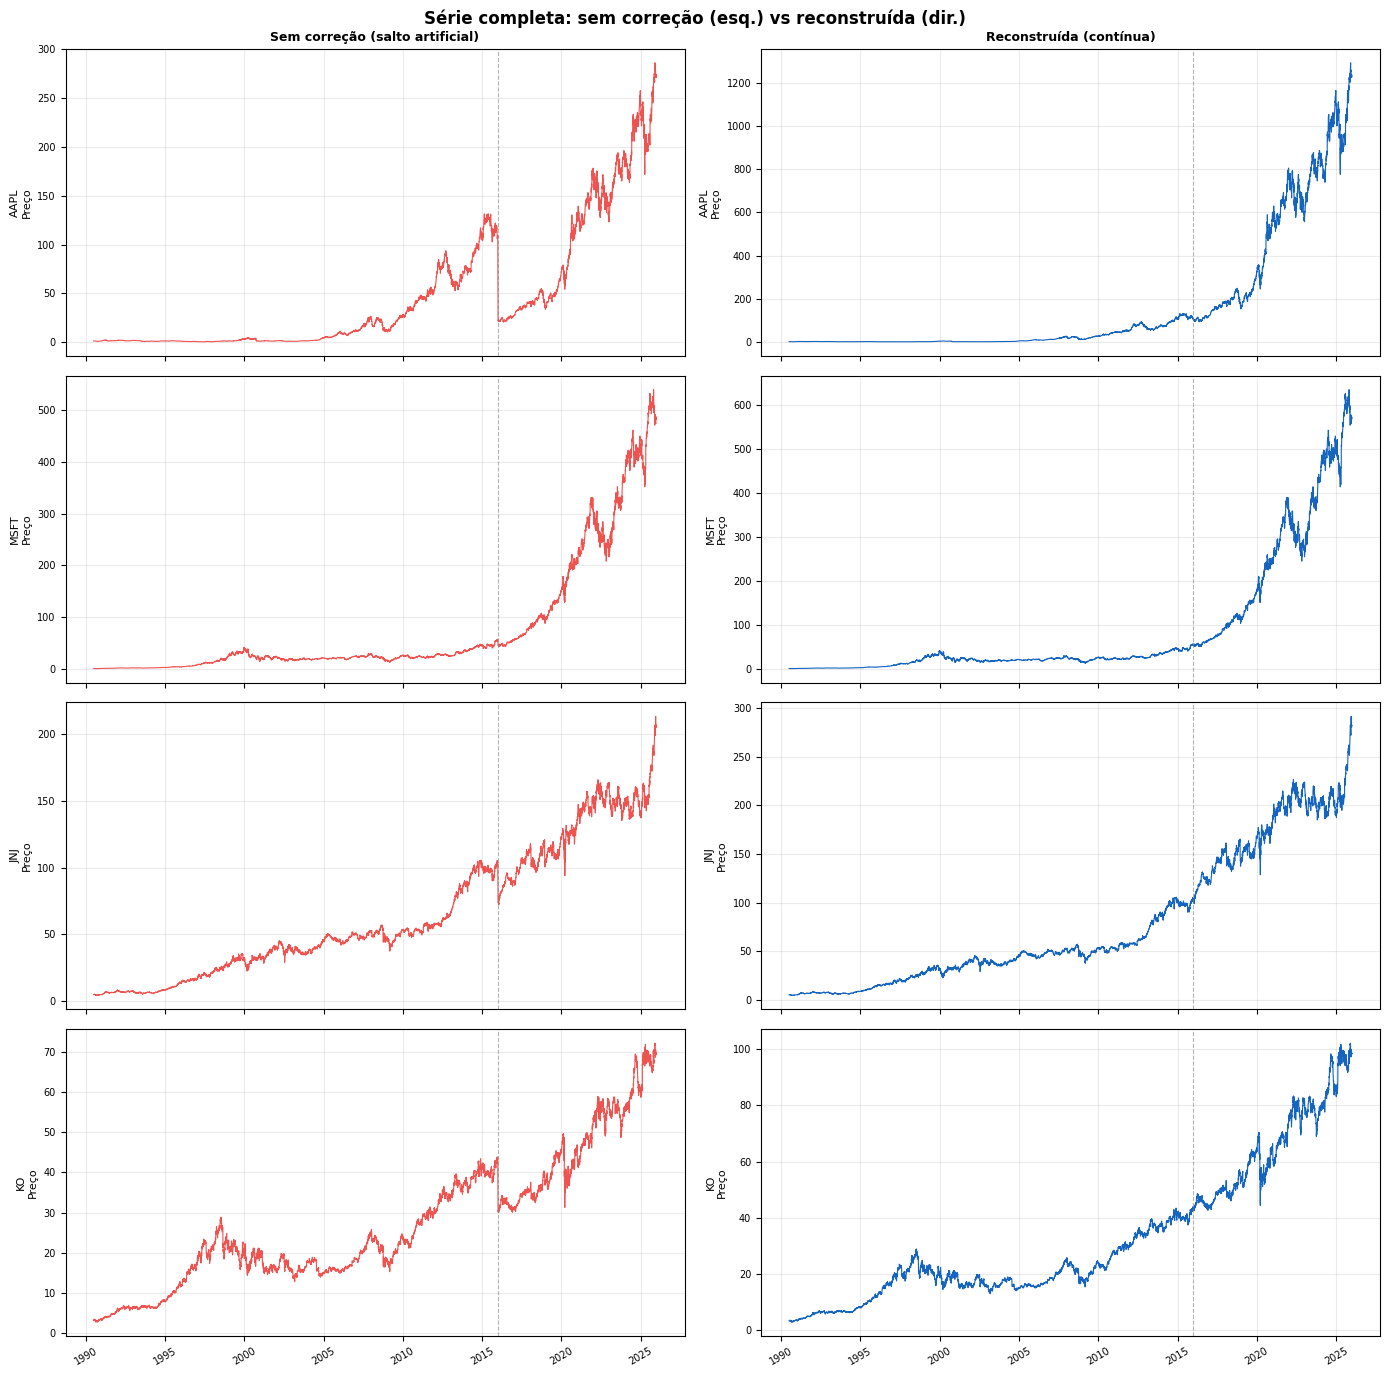

In [10]:
tickers_viz = [t for t in ['AAPL', 'MSFT', 'JNJ', 'KO', 'XOM'] if t in tickers_ambas][:4]

fig, axes = plt.subplots(len(tickers_viz), 2, figsize=(14, 3.5 * len(tickers_viz)), sharex=True)
if len(tickers_viz) == 1:
    axes = [axes]
fig.suptitle('Série completa: sem correção (esq.) vs reconstruída (dir.)', fontsize=12, fontweight='bold')

for i, ticker in enumerate(tickers_viz):
    # Sem correção (concatenação direta)
    serie_raw = pd.concat([prof[ticker], ext[ticker]]).sort_index().dropna()
    # Reconstruída
    serie_uni = base_uni[ticker].dropna()

    for j, (serie, titulo) in enumerate([
        (serie_raw, 'Sem correção (salto artificial)'),
        (serie_uni, 'Reconstruída (contínua)'),
    ]):
        ax = axes[i][j]
        ax.plot(serie.index, serie.values, lw=0.8,
                color='#ef5350' if j == 0 else '#1565C0')
        ax.axvline(pd.Timestamp('2016-01-04'), color='gray', lw=0.8, ls='--', alpha=0.6)
        ax.set_ylabel(f'{ticker}\nPreço', fontsize=8)
        if i == 0:
            ax.set_title(titulo, fontsize=9, fontweight='bold')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 7. Salvando base_unificada.csv

In [11]:
saida = '../data_bases/base_unificada.csv'
base_uni.to_csv(saida)

print(f"Salvo em: {saida}")
print(f"  {base_uni.shape[0]:,} dias de pregão")
print(f"  {n_tickers_uni} tickers únicos")
print(f"  {base_uni.index[0].date()} → {base_uni.index[-1].date()}")
print()
print("Para usar nos notebooks existentes, basta alterar o caminho do CSV:")
print("  pairs_formation.ipynb : trocar 'base_completa.csv' por 'base_unificada.csv'")
print("  pairs_trading.ipynb   : idem")

Salvo em: ../data_bases/base_unificada.csv
  8,939 dias de pregão
  1343 tickers únicos
  1990-07-03 → 2025-12-31

Para usar nos notebooks existentes, basta alterar o caminho do CSV:
  pairs_formation.ipynb : trocar 'base_completa.csv' por 'base_unificada.csv'
  pairs_trading.ipynb   : idem


## 8. Teste de correlação: extensão reconstruída vs. preços reais

Verifica que a reconstrução **não perde informação de mercado**.

Como `ext_rec[t] = ext[t] × fator` (constante por ticker), os retornos diários são idênticos por álgebra:

$$r_{\\text{rec}}(t) = \\frac{P_{\\text{rec}}(t)}{P_{\\text{rec}}(t-1)} - 1 = \\frac{P_{\\text{ext}}(t) \\cdot k}{P_{\\text{ext}}(t-1) \\cdot k} - 1 = r_{\\text{ext}}(t)$$

O teste abaixo quantifica isso numericamente e visualmente para todos os tickers da interseção.

In [12]:
# === 8.1 Correlação de retornos por ticker (todos da interseção) ===
correlacoes = {}
max_diffs   = {}

for ticker in tickers_ambas:
    ext_s = ext[ticker].dropna()
    rec_s = ext_rec[ticker].dropna()

    # Alinha índices e computa retornos
    idx_comum = ext_s.index.intersection(rec_s.index)
    if len(idx_comum) < 10:
        continue

    r_ext = ext_s.loc[idx_comum].pct_change().dropna()
    r_rec = rec_s.loc[idx_comum].pct_change().dropna()

    correlacoes[ticker] = r_ext.corr(r_rec)
    max_diffs[ticker]   = (r_ext - r_rec).abs().max()

corr_s     = pd.Series(correlacoes)
maxdiff_s  = pd.Series(max_diffs)

print("=== Correlação de retornos diários: ext_raw vs ext_reconstruída ===")
print(f"Tickers testados : {len(corr_s)}")
print(f"Correlação mín   : {corr_s.min():.8f}  ({corr_s.idxmin()})")
print(f"Correlação máx   : {corr_s.max():.8f}")
print(f"Correlação média : {corr_s.mean():.8f}")
print(f"Tickers com corr < 0.9999 : {(corr_s < 0.9999).sum()}")
print()
print("=== Diferença máxima nos retornos diários (deve ser ≈ 0) ===")
print(f"max |r_ext - r_rec| global : {maxdiff_s.max():.2e}")
print(f"Tickers com diff > 1e-8    : {(maxdiff_s > 1e-8).sum()}")

=== Correlação de retornos diários: ext_raw vs ext_reconstruída ===
Tickers testados : 465
Correlação mín   : 1.00000000  (ABT)
Correlação máx   : 1.00000000
Correlação média : 1.00000000
Tickers com corr < 0.9999 : 0

=== Diferença máxima nos retornos diários (deve ser ≈ 0) ===
max |r_ext - r_rec| global : 4.44e-16
Tickers com diff > 1e-8    : 0


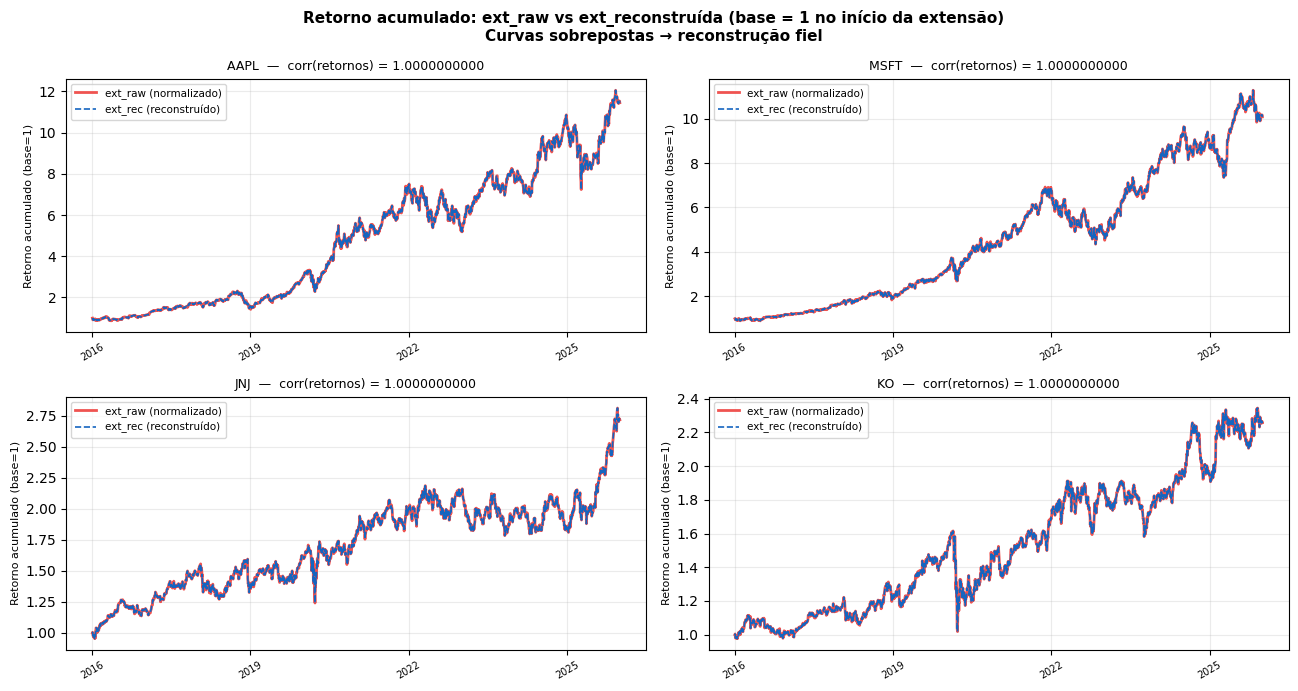

In [13]:
# === 8.2 Retorno acumulado: ext_raw vs ext_reconstruída (4 tickers) ===
# Normaliza ambas a partir de 1 no primeiro dia comum para comparação direta
tickers_corr_plot = [t for t in ['AAPL', 'MSFT', 'JNJ', 'KO'] if t in tickers_ambas]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()
fig.suptitle(
    'Retorno acumulado: ext_raw vs ext_reconstruída (base = 1 no início da extensão)\n'
    'Curvas sobrepostas → reconstrução fiel',
    fontsize=11, fontweight='bold'
)

for ax, ticker in zip(axes, tickers_corr_plot):
    ext_s = ext[ticker].dropna()
    rec_s = ext_rec[ticker].dropna()
    idx   = ext_s.index.intersection(rec_s.index)

    # Normaliza para 1 no primeiro dia (elimina diferença de escala)
    cum_ext = ext_s.loc[idx] / ext_s.loc[idx].iloc[0]
    cum_rec = rec_s.loc[idx] / rec_s.loc[idx].iloc[0]

    ax.plot(cum_ext.index, cum_ext.values, color='#ef5350', lw=2.0,
            label='ext_raw (normalizado)', zorder=2)
    ax.plot(cum_rec.index, cum_rec.values, color='#1565C0', lw=1.2,
            ls='--', label='ext_rec (reconstruído)', zorder=3)

    corr = correlacoes.get(ticker, float('nan'))
    ax.set_title(f'{ticker}  —  corr(retornos) = {corr:.10f}', fontsize=9)
    ax.set_ylabel('Retorno acumulado (base=1)', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

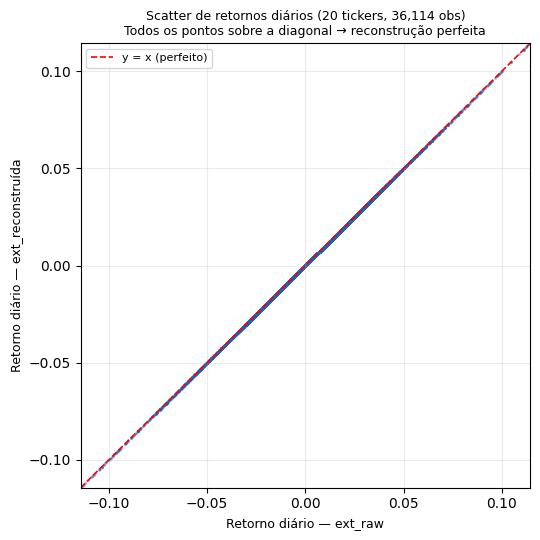


Correlação global (todos os pontos do scatter) : 1.0000000000
Desvio máximo absoluto nos retornos            : 2.22e-16

Conclusão: a reconstrução preserva 100% da informação de mercado.
A única diferença entre ext_raw e ext_rec é o nível absoluto dos preços —
que é exatamente o que queríamos corrigir para eliminar a descontinuidade.


In [14]:
# === 8.3 Scatter: retorno diário ext_raw vs ext_rec (amostra aleatória de datas/tickers) ===
# Se as curvas forem idênticas, todos os pontos devem cair na diagonal y=x
rng = np.random.default_rng(42)
tickers_amostra = rng.choice(list(tickers_ambas), size=min(20, len(tickers_ambas)), replace=False)

r_ext_all, r_rec_all = [], []
for ticker in tickers_amostra:
    ext_s = ext[ticker].dropna()
    rec_s = ext_rec[ticker].dropna()
    idx   = ext_s.index.intersection(rec_s.index)
    r_e   = ext_s.loc[idx].pct_change().dropna()
    r_r   = rec_s.loc[idx].pct_change().dropna()
    r_ext_all.append(r_e)
    r_rec_all.append(r_r)

r_ext_all = pd.concat(r_ext_all)
r_rec_all = pd.concat(r_rec_all)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
lim = max(r_ext_all.abs().quantile(0.998), r_rec_all.abs().quantile(0.998))
ax.scatter(r_ext_all, r_rec_all, s=1.5, alpha=0.3, color='#1565C0', rasterized=True)
ax.plot([-lim, lim], [-lim, lim], color='red', lw=1.2, ls='--', label='y = x (perfeito)')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('Retorno diário — ext_raw',         fontsize=9)
ax.set_ylabel('Retorno diário — ext_reconstruída', fontsize=9)
ax.set_title(
    f'Scatter de retornos diários ({len(tickers_amostra)} tickers, {len(r_ext_all):,} obs)\n'
    f'Todos os pontos sobre a diagonal → reconstrução perfeita',
    fontsize=9
)
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"\nCorrelação global (todos os pontos do scatter) : {r_ext_all.corr(r_rec_all):.10f}")
print(f"Desvio máximo absoluto nos retornos            : {(r_ext_all - r_rec_all).abs().max():.2e}")
print()
print("Conclusão: a reconstrução preserva 100% da informação de mercado.")
print("A única diferença entre ext_raw e ext_rec é o nível absoluto dos preços —")
print("que é exatamente o que queríamos corrigir para eliminar a descontinuidade.")